In [4]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data (1).csv


In [5]:
import pandas as pd
df = pd.read_csv('data.csv',encoding='latin1')
print("the shape of data:",df.shape)
print("first 5 rows:")
df.head()

the shape of data: (541909, 8)
first 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
print("===== DATA INFO =====")
df.info()

===== DATA INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
print("===== MISSING VALUES =====")
print(df.isnull().sum())


===== MISSING VALUES =====
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
print("===== DATA TYPES =====")
print(df.dtypes)


===== DATA TYPES =====
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [9]:
print("===== NUMERIC COLUMNS SUMMARY =====")
print(df.describe())


===== NUMERIC COLUMNS SUMMARY =====
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


In [10]:
print("===== CATEGORICAL COLUMNS SUMMARY =====")
print(df.describe(include='object'))


===== CATEGORICAL COLUMNS SUMMARY =====
       InvoiceNo StockCode                         Description  \
count     541909    541909                              540455   
unique     25900      4070                                4223   
top       573585    85123A  WHITE HANGING HEART T-LIGHT HOLDER   
freq        1114      2313                                2369   

             InvoiceDate         Country  
count             541909          541909  
unique             23260              38  
top     10/31/2011 14:41  United Kingdom  
freq                1114          495478  


In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],format='mixed', dayfirst=True)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print('date column type:',df['InvoiceDate'].dtype)
print('\n first 3 rows with new revenue column:')
print(df[['InvoiceDate','Quantity','UnitPrice','Revenue']].head(3))

date column type: datetime64[ns]

 first 3 rows with new revenue column:
          InvoiceDate  Quantity  UnitPrice  Revenue
0 2010-01-12 08:26:00         6       2.55    15.30
1 2010-01-12 08:26:00         6       3.39    20.34
2 2010-01-12 08:26:00         8       2.75    22.00


In [12]:
df_clean = df[(df['Quantity'] > 0) &
               (df['UnitPrice'] >0) &
              (df['CustomerID'].notnull())].copy()

print(f"original rows:{len(df):,}")
print(f"cleane rows:{len(df_clean):,}")
messy_rows= len(df)-len(df_clean)
per_messy = (messy_rows / len(df))*100

print(f"rows removed:{messy_rows :,}({per_messy:.1f}%)")

original rows:541,909
cleane rows:397,884
rows removed:144,025(26.6%)


In [13]:
print(f"\n clean data shape:{df_clean.shape}")
print(f"\n date range :{df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"countries in clean data:{df_clean['Country'].nunique()}")


 clean data shape:(397884, 9)

 date range :2010-01-12 08:26:00 to 2011-12-10 17:19:00
countries in clean data:37


In [14]:
products_orders = df_clean.groupby('Description')['InvoiceNo'].nunique()
total_orders = df_clean['InvoiceNo'].nunique()
product_proportion = (products_orders / total_orders * 100).round(2)
print(f"total unique orders:{total_orders}")
print(f"\n top 10 products by order proportion:")
print(product_proportion.sort_values(ascending=False).head(10))

total unique orders:18532

 top 10 products by order proportion:
Description
WHITE HANGING HEART T-LIGHT HOLDER    10.64
REGENCY CAKESTAND 3 TIER               9.19
JUMBO BAG RED RETROSPOT                8.63
PARTY BUNTING                          7.44
ASSORTED COLOUR BIRD ORNAMENT          7.42
LUNCH BAG RED RETROSPOT                6.95
SET OF 3 CAKE TINS PANTRY DESIGN       6.18
POSTAGE                                5.93
LUNCH BAG  BLACK SKULL.                5.68
PACK OF 72 RETROSPOT CAKE CASES        5.55
Name: InvoiceNo, dtype: float64


QUESTION 2

In [15]:
avg_price = df_clean.groupby('Description')['UnitPrice'].mean()
print("sample of avg pieces:")
print(avg_price.head())


sample of avg pieces:
Description
4 PURPLE FLOCK DINNER CANDLES    2.324359
50'S CHRISTMAS GIFT BAG LARGE    1.248073
DOLLY GIRL BEAKER                1.243841
I LOVE LONDON MINI BACKPACK      4.138571
I LOVE LONDON MINI RUCKSACK      4.150000
Name: UnitPrice, dtype: float64


In [16]:
top_10 = avg_price.sort_values(ascending=False).head(10)
print("\n top 10 products by avg price:")
print(top_10)


 top 10 products by avg price:
Description
DOTCOM POSTAGE                        744.147500
PICNIC BASKET WICKER 60 PIECES        649.500000
Manual                                175.291585
RUSTIC  SEVENTEEN DRAWER SIDEBOARD    158.076923
REGENCY MIRROR WITH SHUTTERS          156.428571
VINTAGE BLUE KITCHEN CABINET          146.750000
VINTAGE RED KITCHEN CABINET           143.421053
CHEST NATURAL WOOD 20 DRAWERS         118.076923
LOVE SEAT ANTIQUE WHITE METAL         114.024390
VINTAGE POST OFFICE CABINET            66.360000
Name: UnitPrice, dtype: float64


clean postage and all what is not a product


In [20]:
df_only_produts = df_clean[~df_clean['Description'].str.contains('POSTAGE|SHIPPING|DELIVERY', case=False, na=False)].copy()
print(f" Rows after removing postage: {len(df_only_produts):,}")
print(f" Rows removed: {len(df_clean) - len(df_only_produts):,}")

 Rows after removing postage: 396,769
 Rows removed: 1,115


In [27]:
avg_price_clean= df_only_produts.groupby('Description')['UnitPrice'].mean()
top_10_clean = avg_price_clean.sort_values(ascending=False).head(10)
print(" TRUE TOP 10 PRODUCTS BY HIGHEST AVERAGE PRICE (No Postage):")
print("=" * 70)
print(f"{'Rank':<6} {'Product':<40} {'Avg Price (£)':>12}")
print("=" * 70)
for i ,(product,avg_price) in enumerate(top_10_clean.items(),1):
  print(f"{i:<6} {product:<40} {avg_price:12.2f}")
print("=" * 70)
print(f"\n KEY FINDING: {top_10_clean.index[0]} (£{top_10_clean.iloc[0]})")

 TRUE TOP 10 PRODUCTS BY HIGHEST AVERAGE PRICE (No Postage):
Rank   Product                                  Avg Price (£)
1      PICNIC BASKET WICKER 60 PIECES                 649.50
2      Manual                                         175.29
3      RUSTIC  SEVENTEEN DRAWER SIDEBOARD             158.08
4      REGENCY MIRROR WITH SHUTTERS                   156.43
5      VINTAGE BLUE KITCHEN CABINET                   146.75
6      VINTAGE RED KITCHEN CABINET                    143.42
7      CHEST NATURAL WOOD 20 DRAWERS                  118.08
8      LOVE SEAT ANTIQUE WHITE METAL                  114.02
9      VINTAGE POST OFFICE CABINET                     66.36
10     SCHOOL DESK AND CHAIR                           63.92

 KEY FINDING: PICNIC BASKET WICKER 60 PIECES (£649.5)


In [29]:
print('revenue column check:')
print (df_clean[['Quantity','UnitPrice' , 'Revenue']].head(5))

print('manual verification')
first_row= df_clean.iloc[0]
calculated=first_row['Quantity']*first_row['UnitPrice']
print(f"Quantity: {first_row['Quantity']} × UnitPrice: £{first_row['UnitPrice']} = £{calculated}")
print(f"Stored Revenue: £{first_row['Revenue']}")
print(f"Match: {calculated == first_row['Revenue']} ✅")

revenue column check:
   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34
manual verification
Quantity: 6 × UnitPrice: £2.55 = £15.299999999999999
Stored Revenue: £15.299999999999999
Match: True ✅


In [30]:
revenue_by_country= df_clean.groupby('Country')['Revenue'].sum()
top_countries= revenue_by_country.sort_values(ascending=False).head(10)
print("🌍 TOP 10 COUNTRIES BY TOTAL REVENUE:")
print("=" * 60)
print(f"{'Rank':<6} {'Country':<25} {'Total Revenue (£)':>15}")
print("-" * 60)
for i, (country, revenue) in enumerate(top_countries.items(), 1):
    print(f"{i:<6} {country:<25} {revenue:>15,.2f}")
print("=" * 60)

🌍 TOP 10 COUNTRIES BY TOTAL REVENUE:
Rank   Country                   Total Revenue (£)
------------------------------------------------------------
1      United Kingdom               7,308,391.55
2      Netherlands                    285,446.34
3      EIRE                           265,545.90
4      Germany                        228,867.14
5      France                         209,024.05
6      Australia                      138,521.31
7      Spain                           61,577.11
8      Switzerland                     56,443.95
9      Belgium                         41,196.34
10     Sweden                          38,378.33


In [31]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(" Visualization library loaded successfully!")

 Visualization library loaded successfully!


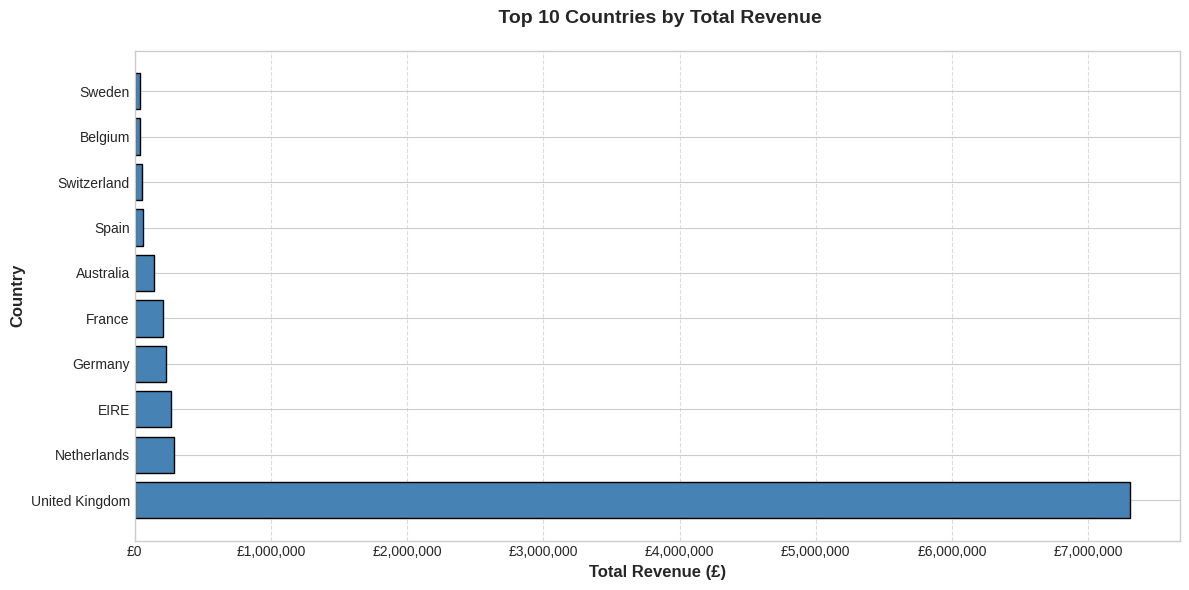

 Chart saved as 'country_revenue_chart.png'


<Figure size 1200x600 with 0 Axes>

In [36]:
plt.figure(figsize=(12, 6))
plt.barh(top_countries.index, top_countries.values, color='steelblue', edgecolor='black')

plt.xlabel('Total Revenue (£)', fontsize=12, fontweight='bold')
plt.ylabel('Country', fontsize=12, fontweight='bold')
plt.title(' Top 10 Countries by Total Revenue', fontsize=14, fontweight='bold', pad=20)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))

plt.yticks(fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
plt.savefig('country_revenue_chart.png', dpi=300, bbox_inches='tight')
print(" Chart saved as 'country_revenue_chart.png'")